# ZWO Camera Timing — All Conditions

Runs the full timing analysis across every dataset in the ZWO_Timing directory:
three ROI sizes (512×512, 1024×1024, 2048×2048) × four nominal frame periods (10, 20, 50, 100 ms).

For each condition the same analysis as the individual notebooks is applied:
- Clipped triangle wave fit to reconstruct the 1 Hz illumination signal
- Trough-counting measurement of the actual frame period from optical data alone
- Host-side delivery jitter characterisation
- Camera-clock linearity and host latency
- Save-latency analysis

All per-condition plots are saved as SVG files.  
All numeric results are aggregated into an HDF5 database.
Summary plots compare frame-period error and jitter across conditions.

In [4]:
import sys

from pyS3M import IOFunctions, PlottingBase

import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tifffile
from scipy import optimize, stats
from scipy.signal import find_peaks

IO = IOFunctions.IO_Functions()
plotter = PlottingBase.PublicationPlotter()

In [5]:
BASE_DIR   = '/media/jbeckwith/JSB_BACKUP_01/ZWO_Timing'
OUTPUT_DIR = BASE_DIR   # SVGs saved alongside raw data
HDF5_PATH  = os.path.join(BASE_DIR, 'ZWO_timing_results.h5')

## 1. Discover conditions

In [6]:
pattern = re.compile(r'(\d+)HzTri_(\d+)ms_(\d+)x(\d+)px')

conditions = []
for folder in sorted(os.listdir(BASE_DIR)):
    m = pattern.match(folder)
    if m is None:
        continue
    data_dir = os.path.join(BASE_DIR, folder, 'Pos-0-0')
    if not os.path.isdir(data_dir):
        continue
    if not os.path.isfile(os.path.join(data_dir, 'timestamps.csv')):
        print(f'  SKIP {folder} — no timestamps.csv')
        continue
    conditions.append(dict(
        folder_name      = folder,
        data_dir         = data_dir,
        freq_hz          = float(m.group(1)),
        nominal_frame_ms = float(m.group(2)),
        width            = int(m.group(3)),
        height           = int(m.group(4)),
    ))

print(f'Found {len(conditions)} conditions:')
for c in conditions:
    print(f"  {c['folder_name']}")

Found 12 conditions:
  1HzTri_100ms_1024x1024px
  1HzTri_100ms_2048x2048px
  1HzTri_100ms_512x512px
  1HzTri_10ms_1024x1024px
  1HzTri_10ms_2048x2048px
  1HzTri_10ms_512x512px
  1HzTri_20ms_1024x1024px
  1HzTri_20ms_2048x2048px
  1HzTri_20ms_512x512px
  1HzTri_50ms_1024x1024px
  1HzTri_50ms_2048x2048px
  1HzTri_50ms_512x512px


## 2. Per-condition analysis loop

For each condition:
1. Load TIFF stack and timestamps
2. Clipped triangle fit (section 2a)
3. Trough-counting frame-rate estimate (section 2b)
4. Host jitter (section 3)
5. Camera clock linearity (section 4)
6. Save latency (section 5)
7. Save all plots as SVGs
8. Collect numeric results

In [7]:
def _tif_sort_key(path):
    m2 = re.search(r'MMStack(?:_(\d+))?\.ome\.tif$', os.path.basename(path))
    return int(m2.group(1)) if m2 and m2.group(1) else 0


def compute_frame_sums(tif_files):
    """Sum pixels per frame across all TIFF files without keeping pixel data in RAM.

    Reads one page at a time so peak memory is a single frame (e.g. ~8 MB for
    2048×2048 uint16) rather than the full multi-file stack.
    """
    sums = []
    for f in tif_files:
        with tifffile.TiffFile(f, is_ome=False, is_mmstack=False, is_imagej=False) as tif:
            for page in tif.pages:
                # Cast to float64 before summing — uint16 sum overflows int32
                # for large ROIs (2048×2048 max ≈ 17 billion counts).
                sums.append(float(page.asarray().astype(np.float64).sum()))
    return np.array(sums, dtype=np.float64)


def clipped_triangle_model(t, A, f, phi, offset, clip_level):
    tri = A * (2.0 / np.pi) * np.arcsin(np.sin(2.0 * np.pi * f * t + phi)) + offset
    return np.minimum(tri, clip_level)


def analyse_condition(cond, output_dir, plotter):
    """Run full timing analysis for one condition.  Returns dict of metrics."""
    folder_name      = cond['folder_name']
    data_dir         = cond['data_dir']
    freq_hz          = cond['freq_hz']
    nominal_frame_ms = cond['nominal_frame_ms']
    width            = cond['width']
    height           = cond['height']

    print(f'\n=== {folder_name} ===')

    # ------------------------------------------------------------------ #
    # Load data — pixel sums only, never the full stack
    # ------------------------------------------------------------------ #
    ts = pd.read_csv(os.path.join(data_dir, 'timestamps.csv'))

    tif_files = sorted(
        glob.glob(os.path.join(data_dir, 'Pos-0-0_MMStack*.ome.tif')),
        key=_tif_sort_key,
    )
    frame_sums = compute_frame_sums(tif_files)

    t_cam_s  = ts['camera_elapsed_ms'].values * 1e-3
    t_cam_ms = ts['camera_elapsed_ms'].values
    t_pop_ms = ts['t_pop_us'].values / 1_000.0
    frames_all = ts['frame'].values

    print(f'  Loaded {len(ts)} frames  ({len(tif_files)} TIFF file(s))')

    svg = lambda name: os.path.join(output_dir, f'{folder_name}_{name}.svg')

    # ------------------------------------------------------------------ #
    # Section 1: raw trace
    # ------------------------------------------------------------------ #
    fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 1], height=5.5)
    plotter.line_plot(
        axs[0], t_cam_s, frame_sums * 1e-6,
        xlabel='Camera elapsed time (s)', ylabel='Total intensity (×10⁶ counts)',
        color='steelblue', linewidth=0.4,
    )
    n_zoom = int(np.ceil(3.0 / (nominal_frame_ms * 1e-3)))
    plotter.line_plot(
        axs[1], t_cam_s[:n_zoom], frame_sums[:n_zoom] * 1e-6,
        xlabel='Camera elapsed time (s)', ylabel='Total intensity (×10⁶ counts)',
        color='steelblue', linewidth=1.0,
    )
    axs[0].set_title('Full acquisition', fontsize=8)
    axs[1].set_title('First 3 periods (zoom)', fontsize=8)
    plotter.save_or_show(fig, save_path=svg('raw'), show=False)
    plt.close(fig)

    # ------------------------------------------------------------------ #
    # Section 2a: clipped triangle fit
    # ------------------------------------------------------------------ #
    clip0   = float(np.percentile(frame_sums, 99.5))
    trough0 = float(np.percentile(frame_sums, 0.5))
    flat_frac   = float((frame_sums > clip0 * 0.9995).mean())
    T_clip_norm = np.cos(flat_frac * np.pi) if flat_frac > 0 else 0.0
    A0      = (clip0 - trough0) / (1.0 + T_clip_norm)
    offset0 = trough0 + A0

    n_search = int(2.0 / (nominal_frame_ms * 1e-3))
    idx_min  = int(np.argmin(frame_sums[:n_search]))
    phi0 = -np.pi / 2.0 - 2.0 * np.pi * freq_hz * t_cam_s[idx_min]
    phi0 = (phi0 + np.pi) % (2.0 * np.pi) - np.pi

    p0 = [A0, freq_hz, phi0, offset0, clip0]
    try:
        popt, pcov = optimize.curve_fit(
            clipped_triangle_model, t_cam_s, frame_sums, p0=p0, maxfev=20_000
        )
        perr = np.sqrt(np.diag(pcov))
    except Exception as e:
        print(f'  WARNING: curve_fit failed — {e}')
        popt = p0
        perr = [np.nan] * 5

    A_fit, f_fit, phi_fit, offset_fit, clip_fit = popt
    fit_vals  = clipped_triangle_model(t_cam_s, *popt)
    residuals = frame_sums - fit_vals
    fitted_flat_frac = float((frame_sums > clip_fit * 0.9995).mean())

    fig, axs = plotter.one_column_plot(npanels=2, ratios=[2, 1], height=5.5)
    t_z   = t_cam_s[:n_zoom]
    fs_z  = frame_sums[:n_zoom]
    fit_z = fit_vals[:n_zoom]
    plotter.line_plot(
        axs[0], t_z, fs_z * 1e-6,
        xlabel='Camera elapsed time (s)', ylabel='Total intensity (×10⁶ counts)',
        color='steelblue', linewidth=1.0, label='Data',
    )
    plotter.line_plot(
        axs[0], t_z, fit_z * 1e-6,
        xlabel='Camera elapsed time (s)', ylabel='Total intensity (×10⁶ counts)',
        color='tomato', linewidth=1.5, linestyle='--',
        label=f'Fit  f = {f_fit:.5f} Hz',
    )
    plotter.line_plot(
        axs[1], t_cam_s, residuals * 1e-6,
        xlabel='Camera elapsed time (s)', ylabel='Residual (×10⁶ counts)',
        color='dimgray', linewidth=0.4,
    )
    axs[1].axhline(0, color='tomato', linewidth=1.0, linestyle='--')
    axs[0].set_title('Clipped triangle wave fit (first 3 periods)', fontsize=8)
    axs[1].set_title('Fit residuals (full acquisition)', fontsize=8)
    plotter.save_or_show(fig, save_path=svg('fit'), show=False)
    plt.close(fig)

    # ------------------------------------------------------------------ #
    # Section 2b: trough counting
    # ------------------------------------------------------------------ #
    min_gap    = int(0.6 / (nominal_frame_ms * 1e-3))
    prominence = (float(np.percentile(frame_sums, 99)) - float(np.percentile(frame_sums, 1))) * 0.4
    trough_idx, _ = find_peaks(-frame_sums, distance=min_gap, prominence=prominence)

    trough_n = np.arange(len(trough_idx))
    slope_tr, intercept_tr, _, _, se_tr = stats.linregress(trough_n, trough_idx)

    period_ms         = 1000.0 / freq_hz
    dt_optical_ms     = period_ms / slope_tr
    dt_optical_err_ms = period_ms * se_tr / slope_tr**2

    trough_fit_pos = np.polyval([slope_tr, intercept_tr], trough_n)
    trough_residuals_frames = trough_idx - trough_fit_pos

    fig, axs = plotter.two_column_plot(nrows=1, ncols=2)
    plotter.line_plot(
        axs[0], ts['frame'].values, frame_sums * 1e-6,
        xlabel='Frame index', ylabel='Total intensity (×10⁶ counts)',
        color='steelblue', linewidth=0.4,
    )
    axs[0].scatter(trough_idx, frame_sums[trough_idx] * 1e-6,
                   color='tomato', s=12, zorder=3, label=f'{len(trough_idx)} troughs')
    axs[0].legend(fontsize=7)
    axs[0].set_title('Detected intensity troughs', fontsize=8)
    plotter.scatter_plot(
        axs[1], trough_n.astype(float), trough_idx.astype(float),
        xlabel='Trough count', ylabel='Frame index',
        color='steelblue', edgecolor='none', size=8, rasterized=False,
    )
    plotter.line_plot(
        axs[1], trough_n.astype(float), trough_fit_pos,
        xlabel='Trough count', ylabel='Frame index',
        color='tomato', linewidth=1.5,
        label=f'slope = {slope_tr:.3f} fr/period',
    )
    axs[1].set_title('Trough positions — linear fit', fontsize=8)
    plotter.save_or_show(fig, save_path=svg('troughs'), show=False)
    plt.close(fig)

    print(f'  Optical Δt = {dt_optical_ms:.4f} ± {dt_optical_err_ms:.4f} ms  '
          f'({(dt_optical_ms-nominal_frame_ms)/nominal_frame_ms*100:+.3f}%)')

    # ------------------------------------------------------------------ #
    # Section 3: host jitter
    # ------------------------------------------------------------------ #
    delta_us   = ts['delta_pop_us'].iloc[1:].values.astype(float)
    frames_1n  = ts['frame'].iloc[1:].values
    nominal_us = nominal_frame_ms * 1_000.0

    # Window scales with nominal period: 0.5× to 2× captures single-frame
    # deliveries at any frame rate (e.g. 5–20 ms at 10 ms, 50–200 ms at 100 ms).
    jitter_lo_us = nominal_us * 0.5
    jitter_hi_us = nominal_us * 2.0
    mask_central = (delta_us > jitter_lo_us) & (delta_us < jitter_hi_us)
    if mask_central.sum() > 5:
        mu_g, sigma_g = stats.norm.fit(delta_us[mask_central])
    else:
        mu_g, sigma_g = np.nan, np.nan

    fig, axs = plotter.two_column_plot(nrows=1, ncols=2)
    plotter.line_plot(
        axs[0], frames_1n, delta_us / 1_000.0,
        xlabel='Frame', ylabel='Inter-frame interval (ms)',
        color='steelblue', linewidth=0.4,
    )
    axs[0].axhline(
        nominal_us / 1_000.0, color='tomato', linewidth=1.2,
        linestyle='--', label=f'Nominal {nominal_frame_ms:.0f} ms',
    )
    axs[0].legend(fontsize=7)
    axs[0].set_title('Host-side inter-frame intervals', fontsize=8)

    bin_max   = max(nominal_frame_ms * 3.0, float(np.percentile(delta_us / 1_000.0, 99.9)) * 1.05)
    bin_width = max(0.5, nominal_frame_ms * 0.02)
    bin_edges = np.arange(0, bin_max, bin_width)
    plotter.histogram_plot(
        axs[1], delta_us / 1_000.0,
        bins=bin_edges,
        xlabel='Inter-frame interval (ms)', ylabel='Count',
        color='steelblue', edgecolor=None, alpha=0.7,
    )
    axs[1].axvline(
        nominal_us / 1_000.0, color='tomato', linewidth=1.2,
        linestyle='--', label=f'Nominal {nominal_frame_ms:.0f} ms',
    )
    if np.isfinite(mu_g):
        x_g = np.linspace(0, bin_max, 500)
        axs[1].plot(
            x_g,
            stats.norm.pdf(x_g, mu_g / 1_000.0, sigma_g / 1_000.0)
            * mask_central.sum() * bin_width,
            color='tomato', linewidth=1.5, linestyle='--',
            label=(
                f'Gaussian ({jitter_lo_us/1000:.0f}–{jitter_hi_us/1000:.0f} ms)\n'
                f'$\\mu$ = {mu_g/1000:.2f} ms, '
                f'$\\sigma$ = {sigma_g/1000:.2f} ms'
            ),
        )
    axs[1].legend(fontsize=7)
    axs[1].set_title('Inter-frame interval histogram', fontsize=8)
    plotter.save_or_show(fig, save_path=svg('jitter'), show=False)
    plt.close(fig)

    n_burst = int((delta_us < jitter_lo_us).sum())
    n_late  = int((delta_us > jitter_hi_us).sum())
    n_total = len(delta_us)

    # ------------------------------------------------------------------ #
    # Section 4: camera clock
    # ------------------------------------------------------------------ #
    cam_coeffs         = np.polyfit(frames_all, t_cam_ms, 1)
    effective_frame_ms = cam_coeffs[0]
    cam_fit_ms         = np.polyval(cam_coeffs, frames_all)
    cam_residuals_ms   = t_cam_ms - cam_fit_ms
    latency_ms = t_pop_ms - t_cam_ms - (t_pop_ms[0] - t_cam_ms[0])

    fig, axs = plotter.two_column_plot(nrows=2, ncols=2)
    plotter.line_plot(
        axs[0, 0], frames_all, cam_residuals_ms,
        xlabel='Frame', ylabel='Camera time residual (ms)',
        color='steelblue', linewidth=0.5,
    )
    axs[0, 0].axhline(0, color='tomato', linewidth=1.0, linestyle='--')
    axs[0, 0].set_title(
        f'Camera clock linearity  (slope = {effective_frame_ms:.4f} ms/frame)',
        fontsize=7,
    )
    plotter.histogram_plot(
        axs[0, 1], cam_residuals_ms,
        bins=50,
        xlabel='Camera time residual (ms)', ylabel='Count',
        color='steelblue', edgecolor=None, alpha=0.7,
    )
    axs[0, 1].set_title('Camera clock residual distribution', fontsize=8)
    plotter.line_plot(
        axs[1, 0], frames_all, latency_ms,
        xlabel='Frame', ylabel='Host − camera latency (ms)',
        color='steelblue', linewidth=0.5,
    )
    axs[1, 0].axhline(0, color='tomato', linewidth=1.0, linestyle='--')
    axs[1, 0].set_title('Host latency relative to camera clock', fontsize=7)
    plotter.histogram_plot(
        axs[1, 1], latency_ms,
        bins=60,
        xlabel='Host − camera latency (ms)', ylabel='Count',
        color='steelblue', edgecolor=None, alpha=0.7,
    )
    axs[1, 1].set_title('Host latency distribution', fontsize=8)
    plotter.save_or_show(fig, save_path=svg('clocks'), show=False)
    plt.close(fig)

    print(f'  Camera clock Δt = {effective_frame_ms:.4f} ms  '
          f'({(effective_frame_ms-nominal_frame_ms)/nominal_frame_ms*100:+.3f}%)')

    # ------------------------------------------------------------------ #
    # Section 5: save latency
    # ------------------------------------------------------------------ #
    save_latency_ms = (ts['t_saved_us'].values - ts['t_pop_us'].values) / 1_000.0
    circ = ts['circ_remaining'].values
    r_save, p_save = stats.pearsonr(circ, save_latency_ms)

    fig, axs = plotter.two_column_plot(nrows=1, ncols=2)
    plotter.histogram_plot(
        axs[0], save_latency_ms,
        bins=80,
        xlabel='Save latency (ms)', ylabel='Count',
        color='steelblue', edgecolor=None, alpha=0.7,
    )
    axs[0].axvline(
        np.median(save_latency_ms), color='tomato', linewidth=1.2, linestyle='--',
        label=f'Median {np.median(save_latency_ms):.2f} ms',
    )
    axs[0].legend(fontsize=7)
    axs[0].set_title('Save latency distribution', fontsize=8)
    plotter.scatter_plot(
        axs[1], circ.astype(float), save_latency_ms,
        xlabel='Buffer frames remaining', ylabel='Save latency (ms)',
        color='steelblue', edgecolor='none', size=4, alpha=0.3, rasterized=True,
    )
    axs[1].set_title('Save latency vs buffer occupancy', fontsize=8)
    axs[1].text(
        0.05, 0.93, f'r = {r_save:.3f},  p = {p_save:.2g}',
        transform=axs[1].transAxes, fontsize=7, va='top',
    )
    plotter.save_or_show(fig, save_path=svg('save_latency'), show=False)
    plt.close(fig)

    # ------------------------------------------------------------------ #
    # Return numeric results
    # ------------------------------------------------------------------ #
    return dict(
        folder_name             = folder_name,
        freq_hz                 = freq_hz,
        nominal_frame_ms        = nominal_frame_ms,
        width                   = width,
        height                  = height,
        n_pixels                = width * height,
        n_frames                = len(ts),
        total_duration_s        = t_cam_ms[-1] / 1000.0,
        # Optical (trough counting)
        n_troughs               = len(trough_idx),
        slope_tr                = float(slope_tr),
        se_tr                   = float(se_tr),
        dt_optical_ms           = float(dt_optical_ms),
        dt_optical_err_ms       = float(dt_optical_err_ms),
        dt_optical_err_pct      = float((dt_optical_ms - nominal_frame_ms) / nominal_frame_ms * 100),
        trough_resid_std_frames = float(trough_residuals_frames.std()),
        # Camera clock
        effective_frame_ms      = float(effective_frame_ms),
        cam_err_pct             = float((effective_frame_ms - nominal_frame_ms) / nominal_frame_ms * 100),
        cam_resid_std_ms        = float(cam_residuals_ms.std()),
        # Waveform fit
        f_fit_hz                = float(f_fit),
        f_fit_err_hz            = float(perr[1]),
        A_fit_cts               = float(A_fit),
        clip_fit_cts            = float(clip_fit),
        offset_fit_cts          = float(offset_fit),
        flat_frac               = float(fitted_flat_frac),
        fit_resid_pct_amp       = float(residuals.std() / abs(A_fit) * 100),
        # Host jitter (window: 0.5–2× nominal frame period)
        host_mean_ms            = float(delta_us.mean() / 1000.0),
        host_std_ms             = float(delta_us.std() / 1000.0),
        host_median_ms          = float(np.median(delta_us) / 1000.0),
        host_min_ms             = float(delta_us.min() / 1000.0),
        host_max_ms             = float(delta_us.max() / 1000.0),
        jitter_mu_ms            = float(mu_g / 1000.0) if np.isfinite(mu_g) else np.nan,
        jitter_sigma_ms         = float(sigma_g / 1000.0) if np.isfinite(sigma_g) else np.nan,
        jitter_lo_ms            = float(jitter_lo_us / 1000.0),
        jitter_hi_ms            = float(jitter_hi_us / 1000.0),
        n_burst_pct             = float(n_burst / n_total * 100),
        n_late_pct              = float(n_late / n_total * 100),
        # Save latency
        save_lat_mean_ms        = float(save_latency_ms.mean()),
        save_lat_median_ms      = float(np.median(save_latency_ms)),
        save_lat_max_ms         = float(save_latency_ms.max()),
        save_lat_r_circ         = float(r_save),
        # Host latency vs camera
        host_cam_lat_mean_ms    = float(latency_ms.mean()),
        host_cam_lat_std_ms     = float(latency_ms.std()),
    )

In [8]:
all_results = []
for cond in conditions:
    result = analyse_condition(cond, OUTPUT_DIR, plotter)
    all_results.append(result)

print(f'\nCompleted {len(all_results)} conditions.')


=== 1HzTri_100ms_1024x1024px ===
  Loaded 5000 frames  (3 TIFF file(s))
  Optical Δt = 100.0685 ± 0.0009 ms  (+0.068%)
  Camera clock Δt = 100.0697 ms  (+0.070%)


/tmp/ipykernel_6564/2453492139.py:297: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_save, p_save = stats.pearsonr(circ, save_latency_ms)



=== 1HzTri_100ms_2048x2048px ===
  Loaded 5000 frames  (10 TIFF file(s))
  Optical Δt = 100.0689 ± 0.0009 ms  (+0.069%)
  Camera clock Δt = 100.0697 ms  (+0.070%)


/tmp/ipykernel_6564/2453492139.py:297: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_save, p_save = stats.pearsonr(circ, save_latency_ms)



=== 1HzTri_100ms_512x512px ===
  Loaded 5000 frames  (1 TIFF file(s))
  Optical Δt = 100.0681 ± 0.0009 ms  (+0.068%)
  Camera clock Δt = 100.0697 ms  (+0.070%)


...


=== 1HzTri_50ms_2048x2048px ===
  Loaded 5000 frames  (10 TIFF file(s))
  Optical Δt = 50.0732 ± 0.0006 ms  (+0.146%)
  Camera clock Δt = 50.0731 ms  (+0.146%)


/tmp/ipykernel_6564/2453492139.py:297: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_save, p_save = stats.pearsonr(circ, save_latency_ms)



=== 1HzTri_50ms_512x512px ===
  Loaded 5000 frames  (1 TIFF file(s))
  Optical Δt = 50.0722 ± 0.0006 ms  (+0.144%)
  Camera clock Δt = 50.0733 ms  (+0.147%)


/tmp/ipykernel_6564/2453492139.py:297: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_save, p_save = stats.pearsonr(circ, save_latency_ms)



Completed 12 conditions.


## 3. Aggregate results and save HDF5

In [9]:
df = pd.DataFrame(all_results).set_index('folder_name')

with pd.HDFStore(HDF5_PATH, mode='w', complevel=5, complib='blosc') as store:
    store.put('results', df, format='table', data_columns=True)

print(f'Saved {len(df)} conditions to {HDF5_PATH}')
display(df[[
    'nominal_frame_ms', 'n_pixels',
    'dt_optical_ms', 'dt_optical_err_ms', 'dt_optical_err_pct',
    'effective_frame_ms', 'cam_err_pct',
    'jitter_sigma_ms', 'n_burst_pct', 'n_late_pct',
]].sort_values(['nominal_frame_ms', 'n_pixels']))

Saved 12 conditions to /media/jbeckwith/JSB_BACKUP_01/ZWO_Timing/ZWO_timing_results.h5


,nominal_frame_ms,n_pixels,dt_optical_ms,dt_optical_err_ms,dt_optical_err_pct,effective_frame_ms,cam_err_pct,jitter_sigma_ms,n_burst_pct,n_late_pct
folder_name,,,,,,,,,,
1HzTri_10ms_512x512px,10.0,262144,10.070233,0.000292,0.702329,10.070396,0.703962,3.941060,27.425485,7.181436
1HzTri_10ms_1024x1024px,10.0,1048576,10.406070,0.000293,4.060704,10.406333,4.063325,3.810775,32.146429,7.621524
1HzTri_10ms_2048x2048px,10.0,4194304,8.854224,0.012770,-11.457765,21.311696,113.116956,2.849497,0.060012,44.388878
1HzTri_20ms_512x512px,20.0,262144,20.072950,0.000402,0.364750,20.073446,0.367231,7.146591,12.942589,0.020004
1HzTri_20ms_1024x1024px,20.0,1048576,20.073499,0.000400,0.367496,20.073400,0.367001,7.387968,14.322865,0.000000
1HzTri_20ms_2048x2048px,20.0,4194304,21.311969,0.000505,6.559843,21.312032,6.560162,7.209248,4.980996,0.040008
1HzTri_50ms_512x512px,50.0,262144,50.072245,0.000646,0.144489,50.073264,0.146529,7.165868,0.000000,0.000000
1HzTri_50ms_1024x1024px,50.0,1048576,50.072518,0.000639,0.145036,50.073258,0.146516,7.529736,0.000000,0.000000
1HzTri_50ms_2048x2048px,50.0,4194304,50.073203,0.000623,0.146406,50.073106,0.146212,8.694989,0.160032,0.000000


## 4. Summary plots

Frame-period error and host jitter as a function of ROI size, grouped by nominal frame period.

In [49]:
max_fps = 46.9
height = 2160
t = 1./max_fps
line_read = t/height

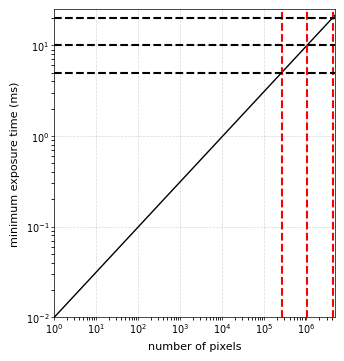

In [83]:
fig, axs = plotter.one_column_plot()

n_lines = np.arange(1, 2161)
axs = plotter.line_plot(axs, n_lines**2, 1000*(n_lines*line_read), ylabel='minimum exposure time (ms)', xlabel='number of pixels')
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlim([1, 2160**2])

axs.vlines(x=512**2, ymin=0, ymax=25, ls='--', color='red')
axs.vlines(x=1024**2, ymin=0, ymax=25, ls='--', color='red')
axs.vlines(x=2048**2, ymin=0, ymax=25, ls='--', color='red')

axs.hlines(y=20, xmin=1, xmax=2160**2, ls='--', color='black')
axs.hlines(y=10, xmin=1, xmax=2160**2, ls='--', color='black')
axs.hlines(y=5, xmin=1, xmax=2160**2, ls='--', color='black')

axs.set_ylim([1e-2, 25])

plotter.save_or_show(
    fig,
    save_path=os.path.join(OUTPUT_DIR, 'ZWO_best_possible.svg'),
    show=True,
)

/tmp/ipykernel_6564/2139379125.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = cm.get_cmap('tab10', n_periods)


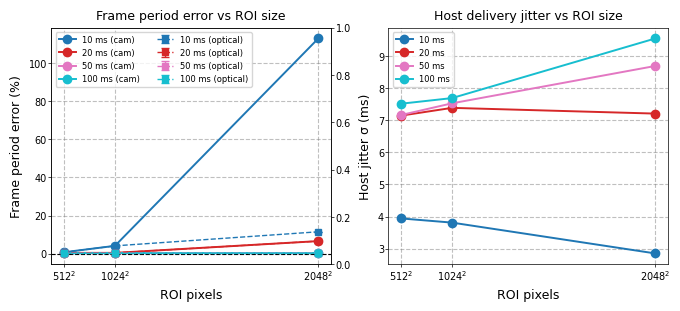

In [79]:
nominal_periods = sorted(df['nominal_frame_ms'].unique())
n_periods = len(nominal_periods)

# Colour cycle: one colour per nominal frame period
cmap   = cm.get_cmap('tab10', n_periods)
colors = {p: cmap(i) for i, p in enumerate(nominal_periods)}
markers = {512**2: 'o', 1024**2: 's', 2048**2: '^'}

# --- Plot A: frame-period error (%) vs n_pixels, methods compared ---
fig, axs = plotter.two_column_plot(nrows=1, ncols=2)

ax2 = axs[0].twinx()

for nom in nominal_periods:
    sub = df[df['nominal_frame_ms'] == nom].sort_values('n_pixels')
    col = colors[nom]
    px  = sub['n_pixels'].values
    # Camera clock
    axs[0].plot(
        px, np.abs(sub['cam_err_pct'].values),
        color=col, linewidth=1.4, linestyle='-',
        marker='o', markersize=6, markerfacecolor=col,
        label=f'{nom:.0f} ms (cam)',
    )
    # Optical
    axs[0].errorbar(
        px, np.abs(sub['dt_optical_err_pct'].values),
        yerr=(sub['dt_optical_err_ms'] / sub['nominal_frame_ms'] * 100).values,
        color=col, linewidth=1.0, linestyle='--',
        marker='s', markersize=5, capsize=3,
        label=f'{nom:.0f} ms (optical)',
    )

axs[0].grid(True, ls='--', alpha=0.5, color='gray')
axs[0].axhline(0, color='k', linewidth=0.8, linestyle='--')
axs[0].set_xlabel('ROI pixels', fontsize=9)
axs[0].set_ylabel('Frame period error (%)', fontsize=9)
axs[0].set_title('Frame period error vs ROI size', fontsize=9)
pixel_vals = sorted(df['n_pixels'].unique())
axs[0].set_xticks(pixel_vals)
axs[0].set_xticklabels([f'{int(p**0.5)}$^2$' for p in pixel_vals], fontsize=7)
axs[0].legend(fontsize=6, ncol=2)

# --- Plot B: host jitter σ vs n_pixels ---
for nom in nominal_periods:
    sub = df[df['nominal_frame_ms'] == nom].sort_values('n_pixels')
    col = colors[nom]
    axs[1].plot(
        sub['n_pixels'].values, sub['jitter_sigma_ms'].values,
        color=col, linewidth=1.4, linestyle='-',
        marker='o', markersize=6, markerfacecolor=col,
        label=f'{nom:.0f} ms',
    )

axs[1].grid(True, ls='--', alpha=0.5, color='gray')
axs[1].set_xlabel('ROI pixels', fontsize=9)
axs[1].set_ylabel('Host jitter σ (ms)', fontsize=9)
axs[1].set_title('Host delivery jitter vs ROI size', fontsize=9)
axs[1].set_xticks(pixel_vals)
axs[1].set_xticklabels([f'{int(p**0.5)}$^2$' for p in pixel_vals], fontsize=7)
axs[1].legend(fontsize=6)

plotter.save_or_show(
    fig,
    save_path=os.path.join(OUTPUT_DIR, 'ZWO_summary_error_vs_pixels_includeoutliers.svg'),
    show=True,
)

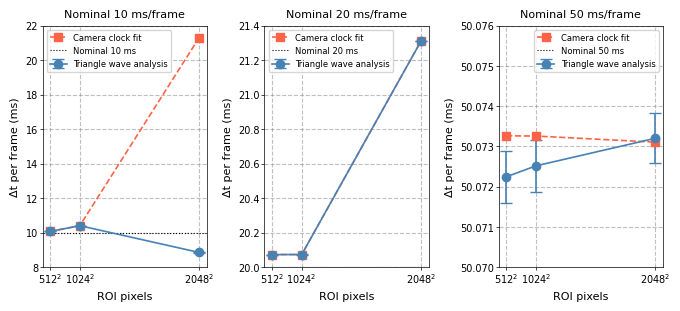

In [81]:
# --- Plot C: frame period (ms) vs n_pixels, one panel per nominal rate ---
fig, axs = plotter.two_column_plot(ncols=3, width_ratios=[1,1,1])
mins = [8, 20, 50.07]
maxs = [22, 21.4, 50.076]
for ax, nom, min, max in zip(axs, nominal_periods, mins, maxs):
    sub = df[df['nominal_frame_ms'] == nom].sort_values('n_pixels')
    px  = sub['n_pixels'].values

    ax.errorbar(
        px, sub['dt_optical_ms'].values,
        yerr=np.abs(sub['dt_optical_err_ms'].values),
        color='steelblue', linewidth=1.2, linestyle='-',
        marker='o', markersize=6, capsize=4,
        label='Triangle wave analysis',
    )
    ax.plot(
        px, sub['effective_frame_ms'].values,
        color='tomato', linewidth=1.2, linestyle='--',
        marker='s', markersize=6,
        label='Camera clock fit',
    )
    ax.axhline(nom, color='k', linewidth=0.8, linestyle=':', label=f'Nominal {nom:.0f} ms')
    ax.set_ylim([min, max])
    ax.set_xlabel('ROI pixels', fontsize=8)
    ax.set_ylabel('Δt per frame (ms)', fontsize=8)
    ax.set_title(f'Nominal {nom:.0f} ms/frame', fontsize=8)
    ax.set_xticks(pixel_vals)
    ax.set_xticklabels([f'{int(p**0.5)}$^2$' for p in pixel_vals], fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, ls='--', alpha=0.5, color='gray')

plotter.save_or_show(
    fig,
    save_path=os.path.join(OUTPUT_DIR, 'ZWO_summary_frame_period_vs_pixels.svg'),
    show=True,
)

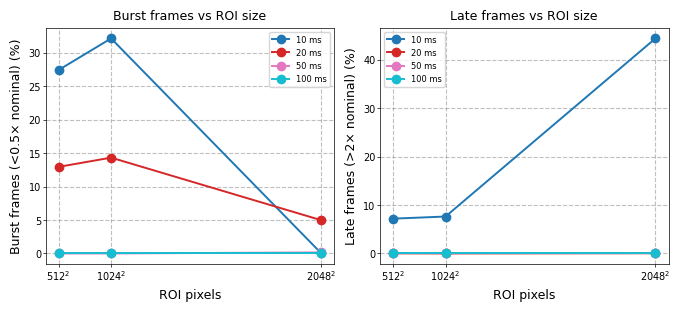

In [48]:
# --- Plot D: burst/late frame percentages vs n_pixels ---
# Burst: delivered in < 0.5× nominal period (two frames batched together)
# Late:  delivered in > 2× nominal period (OS preemption / stall)
fig, axs = plotter.two_column_plot(nrows=1, ncols=2)

for nom in nominal_periods:
    sub = df[df['nominal_frame_ms'] == nom].sort_values('n_pixels')
    col = colors[nom]
    axs[0].plot(
        sub['n_pixels'].values, sub['n_burst_pct'].values,
        color=col, linewidth=1.4, linestyle='-',
        marker='o', markersize=6,
        label=f'{nom:.0f} ms',
    )
    axs[1].plot(
        sub['n_pixels'].values, sub['n_late_pct'].values,
        color=col, linewidth=1.4, linestyle='-',
        marker='o', markersize=6,
        label=f'{nom:.0f} ms',
    )

axs[0].set_xlabel('ROI pixels', fontsize=9)
axs[0].set_ylabel('Burst frames (<0.5× nominal) (%)', fontsize=9)
axs[0].set_title('Burst frames vs ROI size', fontsize=9)
axs[0].set_xticks(pixel_vals)
axs[0].set_xticklabels([f'{int(p**0.5)}$^2$' for p in pixel_vals], fontsize=7)
axs[0].legend(fontsize=6)

axs[1].set_xlabel('ROI pixels', fontsize=9)
axs[1].set_ylabel('Late frames (>2× nominal) (%)', fontsize=9)
axs[1].set_title('Late frames vs ROI size', fontsize=9)
axs[1].set_xticks(pixel_vals)
axs[1].set_xticklabels([f'{int(p**0.5)}$^2$' for p in pixel_vals], fontsize=7)
axs[1].legend(fontsize=6)
for i in np.arange(2):
    axs[i].grid(True, ls='--', alpha=0.5, color='gray')

plotter.save_or_show(
    fig,
    save_path=os.path.join(OUTPUT_DIR, 'ZWO_summary_burst_late_vs_pixels.svg'),
    show=True,
)

In [13]:
print(f'Results database : {HDF5_PATH}')
print(f'SVGs saved in    : {OUTPUT_DIR}')
print()
print('Per-condition SVG files:')
for cond in conditions:
    fn = cond['folder_name']
    for tag in ('raw', 'fit', 'troughs', 'jitter', 'clocks', 'save_latency'):
        print(f'  {fn}_{tag}.svg')
print()
print('Summary SVG files:')
for name in ('ZWO_summary_error_vs_pixels', 'ZWO_summary_frame_period_vs_pixels', 'ZWO_summary_burst_late_vs_pixels'):
    print(f'  {name}.svg')

Results database : /media/jbeckwith/JSB_BACKUP_01/ZWO_Timing/ZWO_timing_results.h5
SVGs saved in    : /media/jbeckwith/JSB_BACKUP_01/ZWO_Timing

Per-condition SVG files:
  1HzTri_100ms_1024x1024px_raw.svg
  1HzTri_100ms_1024x1024px_fit.svg
  1HzTri_100ms_1024x1024px_troughs.svg
  1HzTri_100ms_1024x1024px_jitter.svg
  1HzTri_100ms_1024x1024px_clocks.svg
  1HzTri_100ms_1024x1024px_save_latency.svg
  1HzTri_100ms_2048x2048px_raw.svg
  1HzTri_100ms_2048x2048px_fit.svg
  1HzTri_100ms_2048x2048px_troughs.svg
  1HzTri_100ms_2048x2048px_jitter.svg
  1HzTri_100ms_2048x2048px_clocks.svg
  1HzTri_100ms_2048x2048px_save_latency.svg
  1HzTri_100ms_512x512px_raw.svg
  1HzTri_100ms_512x512px_fit.svg
  1HzTri_100ms_512x512px_troughs.svg
  1HzTri_100ms_512x512px_jitter.svg
  1HzTri_100ms_512x512px_clocks.svg
  1HzTri_100ms_512x512px_save_latency.svg
  1HzTri_10ms_1024x1024px_raw.svg
  1HzTri_10ms_1024x1024px_fit.svg
  1HzTri_10ms_1024x1024px_troughs.svg
  1HzTri_10ms_1024x1024px_jitter.svg
  1HzTri_10m